In [32]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_all_user_json_curves_single(json_dir, max_event=650, model = None):
    """
    Plot average EER (and AUC optionally) curves for all JSON files inside a folder.
    Each JSON file represents a model experiment, and each contributes one curve.

    Parameters
    ----------
    json_dir : str or Path
        Path to the folder containing JSON result files (e.g. 'Training/Results/train_all_user_1DCNN')
    max_event : int
        Maximum number of events to display on the x-axis
    """
    json_dir = Path(json_dir)
    plt.figure(figsize=(8, 5))

    for json_file in json_dir.glob("*.json"):
        try:
            # Set multiplier based on file name
            if "traj" in json_file.stem.lower():
                multiplier = 25.22
            elif "PeakClick" in json_file.stem:
                multiplier = 19.3
            else:
                multiplier = 1.0

            # Skip empty files
            if json_file.stat().st_size == 0:
                print(f"[SKIP] Empty file: {json_file.name}")
                continue

            # Load JSON data
            with open(json_file, "r") as f:
                data = json.load(f)

            # Aggregate per-user results
            user_eers = []
            ns = None
            for user, records in data.items():
                n_vals = []
                eers = []
                for k, v in records.items():
                    n_vals.append(v["n"])
                    eers.append(v["EER"])
                user_eers.append(eers)
                ns = n_vals  # same for all users

            # Compute average EER across users
            user_eers = np.array(user_eers)
            avg_eer = np.mean(user_eers, axis=0)

            # Compute event x-axis
            events = np.array(ns) * multiplier
            mask = events <= max_event
            events = events[mask]
            avg_eer = avg_eer[mask]

            plt.plot(events, avg_eer, marker='o', linewidth=1.8, label=json_file.stem)

        except Exception as e:
            print(f"[ERROR] Failed to process {json_file.name}: {e}")
            continue

    plt.xlabel("Events", fontsize=12)
    plt.ylabel("Average EER", fontsize=12)
    plt.title(f"{model} (Max = {max_event})", fontsize=13, weight='bold')
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [33]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# color fixed
chunk_color_map = {
    "PeakClick": "tab:blue",
    "10": "tab:blue",
    "15": "tab:orange",
    "30": "tab:green",
    "60": "tab:red",
    "120": "tab:purple",
    "300": "tab:brown"
}

def plot_chunk_json_curves(json_dir, max_event=650, model=None):
    json_dir = Path(json_dir)
    plt.figure(figsize=(8, 5))

    for json_file in json_dir.glob("*.json"):
        try:
            name = json_file.stem

            if "PeakClick" in name:
                multiplier = 19.3
                chunk_key = "PeakClick"
            else:
                match = re.search(r"ChunkSize(\d+)", name)
                chunk_key = match.group(1) if match else None
                multiplier = float(chunk_key) if chunk_key else 1.0

            color = chunk_color_map.get(chunk_key, "black")

            with open(json_file, "r") as f:
                data = json.load(f)

            n = np.array(data["n"])
            avg_eer = np.array(data["avg_eer"])
            events = n * multiplier

            mask = events <= max_event
            events = events[mask]
            avg_eer = avg_eer[mask]

            plt.plot(events, avg_eer, marker='o', linewidth=1.8,
                     color=color, label=name)

        except Exception as e:
            print(f"[ERROR] Failed to process {json_file.name}: {e}")
            continue

    plt.xlabel("Events", fontsize=12)
    plt.ylabel("Average EER", fontsize=12)
    plt.title(f"{model} (Chunk Size Experiments)", fontsize=13, weight="bold")
    plt.grid(True, linestyle="--", alpha=0.6)

    # ---- chunk size ranking ----
    handles, labels = plt.gca().get_legend_handles_labels()

    def extract_size(label):
        if "PeakClick" in label:
            return -1
        m = re.search(r"ChunkSize(\d+)", label)
        return int(m.group(1)) if m else 999999

    sorted_pairs = sorted(zip(handles, labels), key=lambda x: extract_size(x[1]))
    sorted_handles, sorted_labels = zip(*sorted_pairs)

    plt.legend(sorted_handles, sorted_labels, fontsize=10)

    plt.tight_layout()
    plt.show()


In [34]:
import re
chunk_color_map = {
    "PeakClick": "tab:blue",
    "10": "tab:blue",
    "15": "tab:orange",
    "30": "tab:green",
    "60": "tab:red",
    "120": "tab:purple",
    "300": "tab:brown"
}


def parse_chunk_size_from_filename(fname):
    """
    ChunkSize120BinaryViT.json -> "120"
    """
    match = re.search(r"ChunkSize(\d+)", fname)
    if match is None:
        raise ValueError(f"Cannot parse chunk size from {fname}")
    return match.group(1)   

import json
import numpy as np

def load_avg_eer_from_json(json_path, chunk_size, max_event=None):
    """
    Compute average EER vs #events (NOT images).
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    eer_by_event = {}

    for user, records in data.items():
        for n_str, metrics in records.items():
            n_img = int(n_str)
            n_event = n_img * chunk_size   

            if max_event is not None and n_event > max_event:
                continue

            eer = metrics.get("EER", None)
            if eer is None:
                continue

            eer_by_event.setdefault(n_event, []).append(eer)

    events = sorted(eer_by_event.keys())
    avg_eer = [np.mean(eer_by_event[e]) for e in events]

    return np.array(events), np.array(avg_eer)

import os
import matplotlib.pyplot as plt

import os
import matplotlib.pyplot as plt

def plot_avg_eer_curves(base_dir, max_event=650, model=None):
    plt.figure(figsize=(8, 5))

    curves = []

    for fname in os.listdir(base_dir):
        if not fname.endswith(".json"):
            continue

        chunk = parse_chunk_size_from_filename(fname)  # "10", "15", ...
        if chunk not in chunk_color_map:
            continue

        json_path = os.path.join(base_dir, fname)

        events, avg_eer = load_avg_eer_from_json(
            json_path,
            chunk_size=int(chunk),
            max_event=max_event
        )

        curves.append((int(chunk), events, avg_eer))

    
    curves.sort(key=lambda x: x[0])


    for chunk, events, avg_eer in curves:
        plt.plot(
            events,
            avg_eer,
            marker="o",
            linewidth=2,
            color=chunk_color_map[str(chunk)],
            label=f"ChunkSize{chunk}MultiViT"
        )

    plt.xlabel("# Events")
    plt.ylabel("Average EER")
    plt.title(
        f"Average EER vs #Events\n{model}"
        if model else "Average EER vs #Events"
    )

    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [35]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# =========================
# Fixed color map
# =========================
chunk_color_map = {
    "PeakClick": "tab:blue",
    "10": "tab:blue",
    "15": "tab:orange",
    "30": "tab:green",
    "60": "tab:red",
    "120": "tab:purple",
    "300": "tab:brown"
}

# =========================
# Plot XY + CDF together
# =========================
def plot_chunk_xy_cdf_curves(
    xy_dir,
    cdf_dir,
    max_event=650,
    model=None,
    title=None
):
    xy_dir = Path(xy_dir)
    cdf_dir = Path(cdf_dir)

    plt.figure(figsize=(9, 5))

    # -------------------------
    # Internal plotting helper
    # -------------------------
    def plot_from_dir(json_dir, linestyle, suffix):
        for json_file in json_dir.glob("*.json"):
            try:
                name = json_file.stem

                # ---- chunk key & multiplier ----
                if "PeakClick" in name:
                    chunk_key = "PeakClick"
                    multiplier = 19.3
                else:
                    match = re.search(r"ChunkSize(\d+)", name)
                    chunk_key = match.group(1) if match else None
                    multiplier = float(chunk_key) if chunk_key else 1.0

                color = chunk_color_map.get(chunk_key, "black")

                # ---- load JSON ----
                with open(json_file, "r") as f:
                    data = json.load(f)

                n = np.array(data["n"])
                avg_eer = np.array(data["avg_eer"])
                events = n * multiplier

                mask = events <= max_event
                events = events[mask]
                avg_eer = avg_eer[mask]

                label = f"{name} ({suffix})"

                plt.plot(
                    events,
                    avg_eer,
                    linestyle=linestyle,
                    linewidth=2,
                    marker="o",
                    markersize=4,
                    color=color,
                    label=label
                )

            except Exception as e:
                print(f"[ERROR] Failed to process {json_file.name}: {e}")

    # -------------------------
    # Plot XY (solid) + CDF (dashed)
    # -------------------------
    plot_from_dir(xy_dir, linestyle="-",  suffix="XY")
    plot_from_dir(cdf_dir, linestyle="--", suffix="CDF")

    # -------------------------
    # Axes & title
    # -------------------------
    plt.xlabel("Events", fontsize=12)
    plt.ylabel("Average EER", fontsize=12)

    if title is not None:
        plt.title(title, fontsize=13, weight="bold")
    else:
        plt.title(
            f"{model} (Chunk Size: XY vs CDF)",
            fontsize=13,
            weight="bold"
        )

    plt.grid(True, linestyle="--", alpha=0.6)

    # -------------------------
    # Legend sorting by chunk size
    # -------------------------
    handles, labels = plt.gca().get_legend_handles_labels()

    def extract_size(label):
        if "PeakClick" in label:
            return -1
        m = re.search(r"ChunkSize(\d+)", label)
        return int(m.group(1)) if m else 999999

    sorted_pairs = sorted(
        zip(handles, labels),
        key=lambda x: extract_size(x[1])
    )

    sorted_handles, sorted_labels = zip(*sorted_pairs)

    plt.legend(
        sorted_handles,
        sorted_labels,
        fontsize=9,
        ncol=2,
        frameon=False
    )

    plt.tight_layout()
    plt.show()


## LOSO

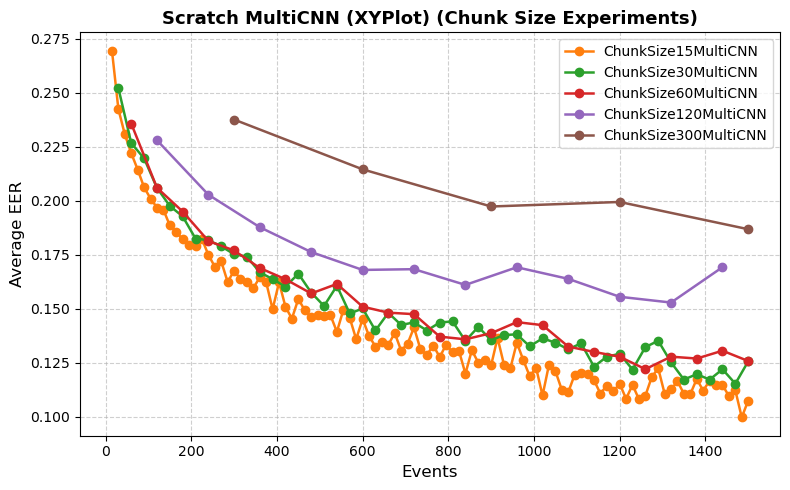

In [36]:
plot_chunk_json_curves("Visualization/CV/train_multi_CNN/XYPlot", max_event=1500, model="Scratch MultiCNN (XYPlot)")

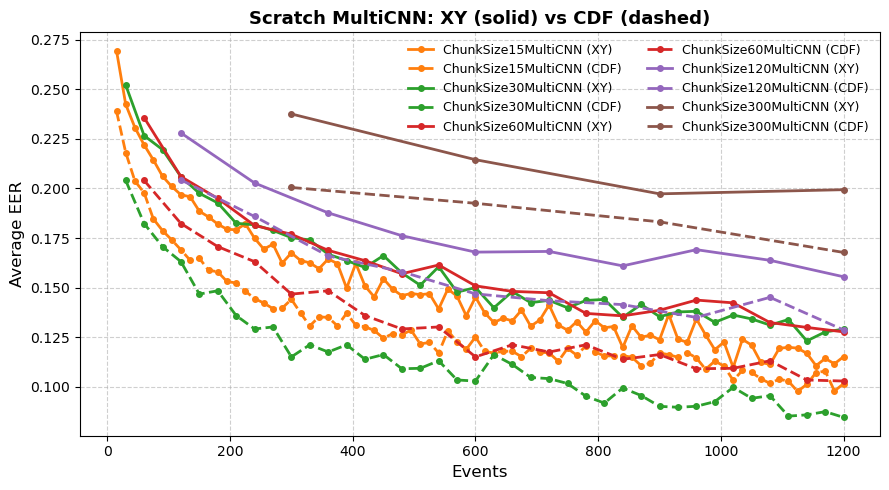

In [37]:
plot_chunk_xy_cdf_curves(
    xy_dir="Visualization/CV/train_multi_CNN/XYPlot",
    cdf_dir="Visualization/CV/train_multi_CNN/cdf",
    title="Scratch MultiCNN: XY (solid) vs CDF (dashed)",
    max_event=1200
)

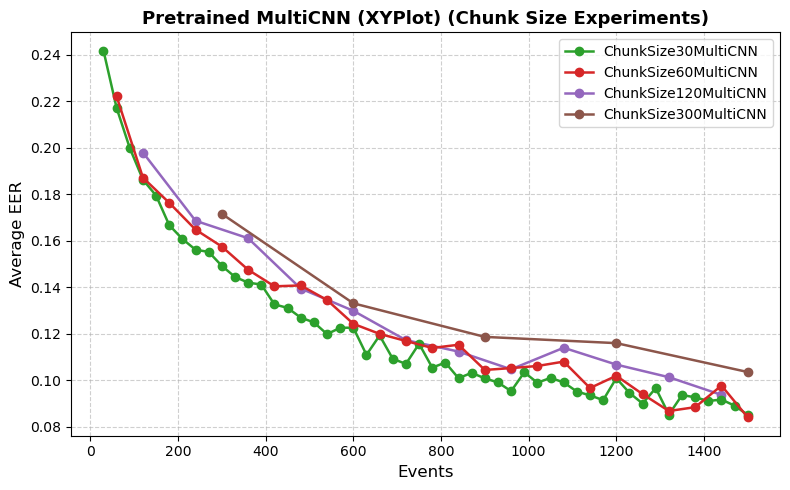

In [38]:
plot_chunk_json_curves("Visualization/Testing_pixel_vs_chunk", max_event=1500, model="Pretrained MultiCNN (XYPlot)")

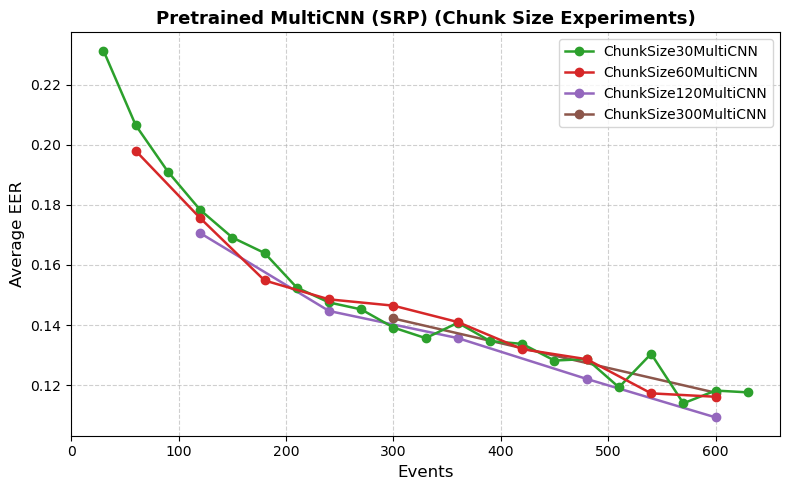

In [39]:
plot_chunk_json_curves("Visualization/Testing_pixel_vs_chunk_SRP", max_event=650, model="Pretrained MultiCNN (SRP)")

## XYPlot + CDF

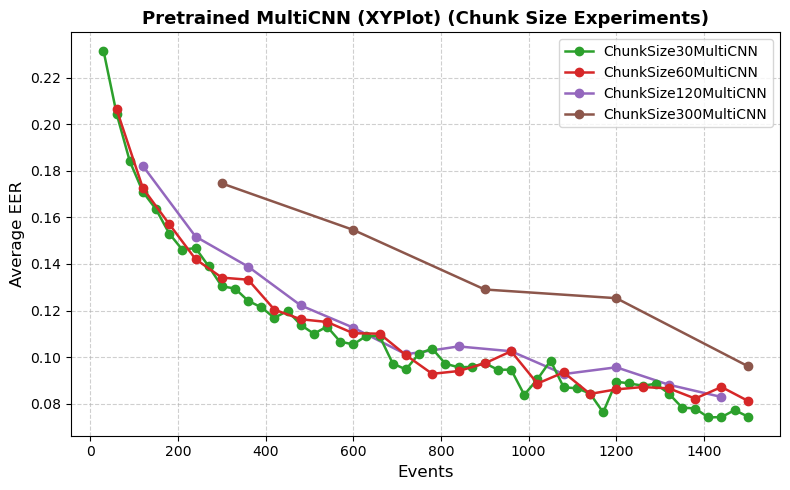

In [40]:
plot_chunk_json_curves("Visualization/Test", max_event=1500, model="Pretrained MultiCNN (XYPlot)")